# 🏢 Employee Attrition Prediction

## Machine Learning Classification Project

**Objective:**
Build a machine learning model to predict whether an employee is likely to leave a company based on job satisfaction, salary, experience, and workplace factors.

**Tools Used:**
Python | Pandas | NumPy | Scikit-learn | Matplotlib | Seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


## Task 1 — Data Loading & Exploration

Loading the HR Employee Attrition dataset.

In [4]:
df = pd.read_csv("HR_Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Dataset Preview
Displaying the first 10 rows of the dataset.

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Dataset Dimensions

Checking number of rows and columns.

### Dataset Dimensions

Checking number of rows and columns.

In [6]:
df.shape

(1470, 35)

### Column Information

Checking data types and identifying numeric and categorical columns.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### Target Variable

The target column is Attrition (Yes/No), which indicates whether an employee left the company.

In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

### Attrition Rate Analysis

Calculating the percentage of employees who left the company.

In [10]:
attrition_rate = (
    df['Attrition'].value_counts()['Yes'] /
    len(df)
) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


### Feature Type Analysis

Separating numeric and categorical columns.

In [11]:
numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns

categorical_cols = df.select_dtypes(
    include=['object']
).columns


print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9

Categorical Columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Missing Value Check

Checking whether the dataset contains missing values.

In [12]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

The attrition rate is around 16%, meaning the dataset is imbalanced.
Most employees stayed in the company, while a smaller percentage left.
This imbalance needs to be considered while training machine learning models.

# Task 2 — Data Cleaning & Preprocessing

Cleaning data, removing irrelevant columns, encoding categorical variables, and scaling features.

In [13]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Removing irrelevant columns

EmployeeNumber, Over18, and StandardHours do not contribute meaningful information for prediction.

In [14]:
df.drop(
    ['EmployeeNumber','Over18','StandardHours'],
    axis=1,
    inplace=True
)

df.shape

(1470, 32)

### Converting Attrition into Binary Format

Yes = 1 (Employee left)

No = 0 (Employee stayed)

In [15]:
df['Attrition'] = df['Attrition'].map(
    {'Yes':1, 'No':0}
)

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

### Encoding Categorical Variables

Converting categorical columns into numerical format using one-hot encoding.

In [16]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,3,61,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,92,2,1,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,4,56,3,1,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,1,40,3,1,...,True,False,False,False,False,False,False,True,False,False


In [17]:
df.shape

(1470, 46)

In [18]:
df.dtypes.value_counts()

int64    25
bool     21
Name: count, dtype: int64

### Separating Features and Target Variable

Attrition is the target variable.

In [19]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']


print("Features:", X.shape)
print("Target:", y.shape)

Features: (1470, 45)
Target: (1470,)


In [20]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 45)
Testing Data: (294, 45)


### Feature Scaling

Scaling numeric features so that all variables are on a similar range.

In [21]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("Scaling completed successfully")

Scaling completed successfully


# Task 3 — Exploratory Data Analysis (EDA)

Analyzing patterns behind employee attrition and identifying factors that influence employee exits.

In [22]:
eda_df = pd.read_csv("HR_Attrition.csv")

eda_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [23]:
eda_df['Attrition'] = eda_df['Attrition'].map(
    {'Yes':1,'No':0}
)

eda_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Attrition Rate by Department

In [24]:
import os
os.makedirs("charts", exist_ok=True)

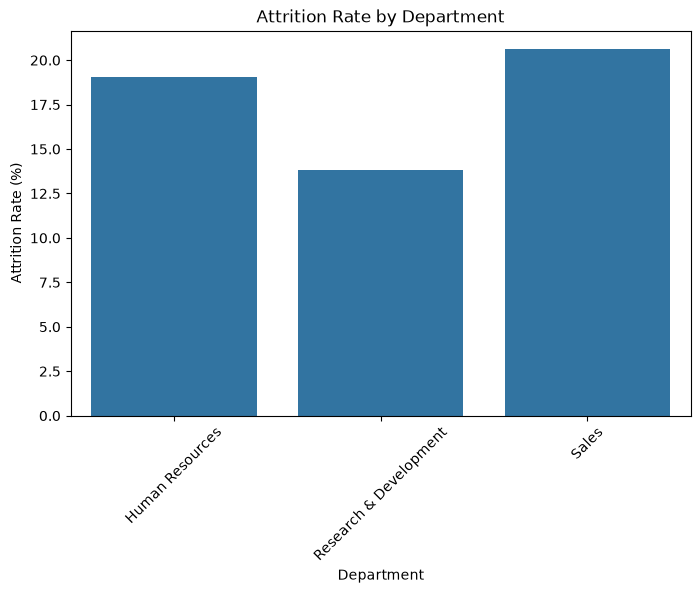

In [25]:
dept_attrition = (
    eda_df.groupby('Department')['Attrition']
    .mean()*100
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=dept_attrition.index,
    y=dept_attrition.values
)

plt.title("Attrition Rate by Department")

plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")

plt.xticks(rotation=45)

plt.savefig("charts/attrition_department.png")

plt.show()

### Attrition Rate by Job Role

Analyzing which job roles have the highest employee exit rate.

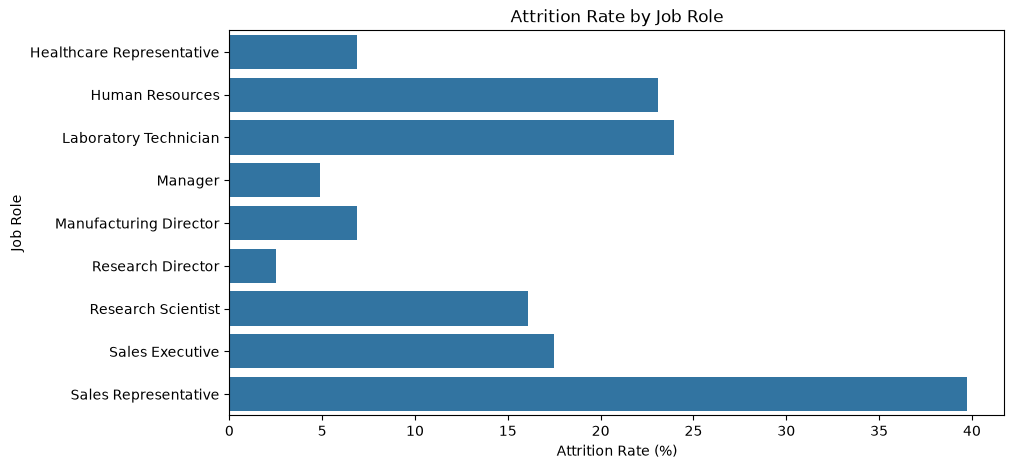

In [26]:
role_attrition = (
    eda_df.groupby('JobRole')['Attrition']
    .mean()*100
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=role_attrition.values,
    y=role_attrition.index
)

plt.title("Attrition Rate by Job Role")

plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.savefig("charts/attrition_jobrole.png",
            bbox_inches="tight")

plt.show()

### Monthly Income vs Attrition

Comparing income distribution between employees who stayed and employees who left.

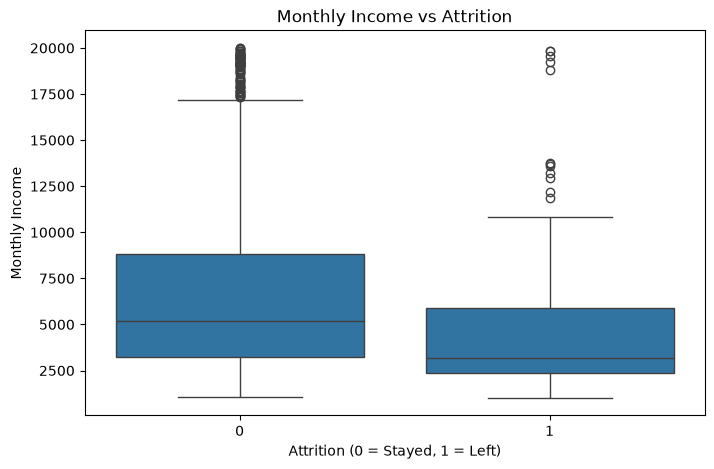

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=eda_df
)

plt.title("Monthly Income vs Attrition")

plt.xlabel("Attrition (0 = Stayed, 1 = Left)")
plt.ylabel("Monthly Income")

plt.savefig("charts/income_boxplot.png",
            bbox_inches="tight")

plt.show()

### Attrition vs Work-Life Balance

Analyzing whether work-life balance affects employee retention.

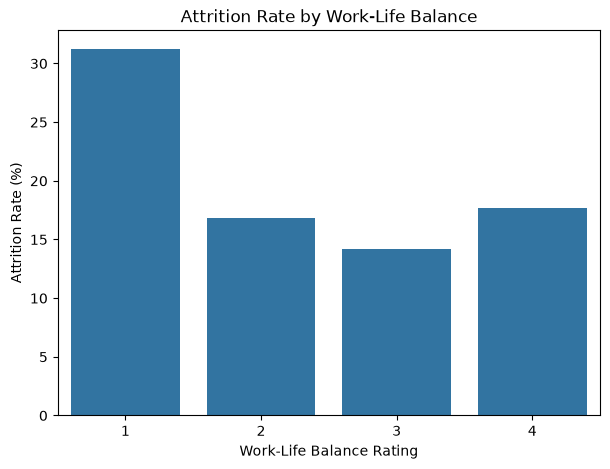

In [28]:
wlb_attrition = (
    eda_df.groupby('WorkLifeBalance')['Attrition']
    .mean()*100
)

plt.figure(figsize=(7,5))

sns.barplot(
    x=wlb_attrition.index,
    y=wlb_attrition.values
)

plt.title("Attrition Rate by Work-Life Balance")

plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.savefig("charts/worklife_balance.png",
            bbox_inches="tight")

plt.show()

### Attrition vs Years at Company

Understanding when employees are most likely to leave.

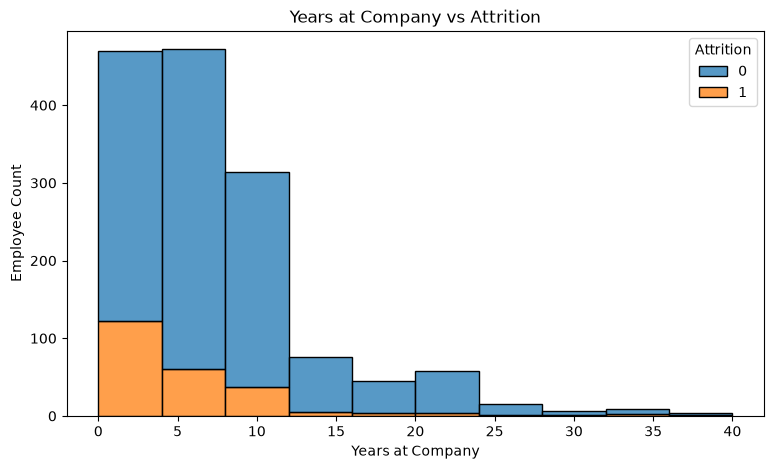

In [29]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=eda_df,
    x="YearsAtCompany",
    hue="Attrition",
    multiple="stack",
    bins=10
)

plt.title("Years at Company vs Attrition")

plt.xlabel("Years at Company")
plt.ylabel("Employee Count")

plt.savefig("charts/years_company_attrition.png",
            bbox_inches="tight")

plt.show()

## EDA Business Insights

1. Sales department has the highest attrition rate compared to other departments.
2. Sales Representatives show the highest employee turnover.
3. Employees with lower monthly income have a higher tendency to leave.
4. Work-life balance has a relationship with employee retention.
5. Employees in early years of employment are more likely to leave.

In [30]:
class_weight='balanced'

# Task 4 — Model Building & Comparison

Training multiple classification models and comparing their performance.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score
)

## Logistic Regression Model

Logistic Regression is used as a baseline classification model because it is simple and explainable for HR decision-making.

In [33]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_scaled,
    y_train
)

lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]


print("Logistic Regression completed")

Logistic Regression completed


## Random Forest Classifier

Random Forest combines multiple decision trees to improve prediction performance and capture complex patterns.

In [34]:
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]


print("Random Forest completed")

Random Forest completed


## Gradient Boosting Classifier

Gradient Boosting builds models sequentially to reduce errors and improve classification accuracy.

In [35]:
gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(X_test)

gb_prob = gb_model.predict_proba(X_test)[:,1]


print("Gradient Boosting completed")

Gradient Boosting completed


## Model Performance Comparison

Evaluating models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

In [36]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ],
    
    "ROC-AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, gb_prob)
    ]
})


results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.812925,0.366667,0.234043,0.285714,0.780774
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.793436


# Task 5 — Model Evaluation

Evaluating model performance using confusion matrix, classification metrics, ROC curve, and feature importance.

In [37]:
print("Gradient Boosting Classification Report")

print(
    classification_report(
        y_test,
        gb_pred
    )
)

Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



## Confusion Matrix — Gradient Boosting

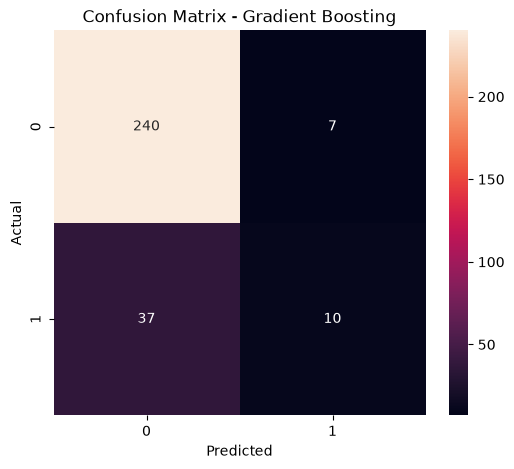

In [38]:
cm = confusion_matrix(
    y_test,
    gb_pred
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix - Gradient Boosting")

plt.xlabel("Predicted")
plt.ylabel("Actual")


plt.savefig(
    "charts/confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

## ROC Curve Comparison

Comparing the ability of all three models to separate employees who leave and stay.

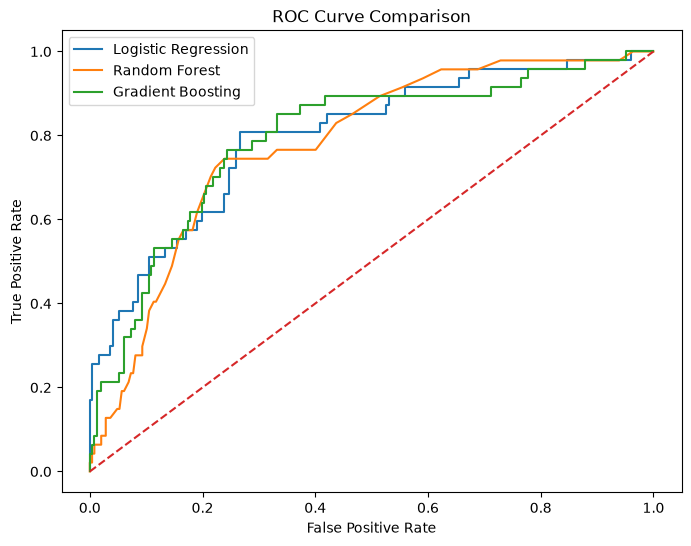

In [39]:
plt.figure(figsize=(8,6))


for model_name, prob in [
    ("Logistic Regression", lr_prob),
    ("Random Forest", rf_prob),
    ("Gradient Boosting", gb_prob)
]:

    fpr, tpr, _ = roc_curve(
        y_test,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        label=model_name
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)


plt.title("ROC Curve Comparison")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()


plt.savefig(
    "charts/roc_curve.png",
    bbox_inches="tight"
)

plt.show()

## Feature Importance

Identifying the top factors influencing employee attrition.

In [40]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": gb_model.feature_importances_
})


importance = importance.sort_values(
    by="Importance",
    ascending=False
)


top_features = importance.head(10)

top_features

,Feature,Importance
10,MonthlyIncome,0.109081
0,Age,0.093560
44,OverTime_Yes,0.088694
17,TotalWorkingYears,0.084067
12,NumCompaniesWorked,0.050086
16,StockOptionLevel,0.047109
1,DailyRate,0.045122
23,YearsWithCurrManager,0.043000
5,EnvironmentSatisfaction,0.038851
7,JobInvolvement,0.038142


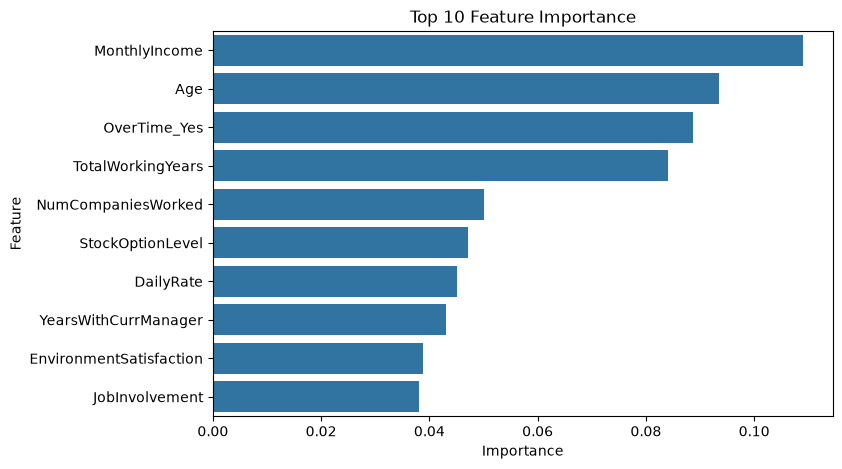

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importance")


plt.savefig(
    "charts/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

# Task 7 — HR Insights & Business Recommendations

Translating machine learning results into actionable HR strategies.

## HR Insights & Recommendations

The analysis shows that employee attrition is mainly influenced by monthly income, age, overtime requirements, and total work experience.

Employees with lower income levels and those working overtime show higher chances of leaving the organization. Sales Representatives and Sales department employees have higher attrition rates compared to other groups.

The model achieved around 85% accuracy in predicting employee attrition. However, since employee turnover depends on human behavior, predictions should be used as a support tool rather than the only decision-making factor.

HR teams should focus on improving compensation strategies, monitoring employees with high overtime workloads, and conducting regular engagement surveys.

Employees with low satisfaction and involvement scores should receive targeted retention efforts before they decide to leave.

In [42]:
import os

os.listdir("charts")

['attrition_department.png',
 'attrition_jobrole.png',
 'confusion_matrix.png',
 'feature_importance.png',
 'income_boxplot.png',
 'roc_curve.png',
 'worklife_balance.png',
 'years_company_attrition.png']

# Employee Attrition Prediction — Project Summary

## Executive Summary

This project analyzes employee data to identify patterns that influence employee attrition and help organizations improve retention strategies.

The analysis found that the most important factors affecting employee turnover are monthly income, employee age, overtime requirements, total working experience, and job satisfaction-related factors.

The Sales department and Sales Representative role showed higher attrition rates compared to other departments and roles.

Machine learning models were trained to predict whether an employee is likely to leave the organization. Among the tested models, Gradient Boosting achieved the highest accuracy of approximately 85%.

The results show that salary is an important factor, but employee retention also depends on workload, career growth, satisfaction, and workplace environment.

Based on these findings, HR teams should focus on reviewing compensation, reducing excessive overtime, improving employee engagement, and proactively supporting employees who show signs of disengagement.

The model should be used as a decision-support tool and not as the only factor for employee-related decisions.

In [43]:
from docx import Document

doc = Document()

doc.add_heading(
    "Employee Attrition Prediction - Summary",
    level=1
)

doc.add_paragraph("""
This project analyzes employee data to identify patterns that influence employee attrition and help organizations improve retention strategies.

The analysis found that monthly income, age, overtime, total working years, and satisfaction factors strongly influence employee turnover.

Sales department and Sales Representative roles showed higher attrition.

Gradient Boosting performed best among tested models with approximately 85% accuracy.

HR teams can use these insights to improve compensation, reduce excessive overtime, and create targeted retention strategies.

The model should support HR decisions rather than replace human judgement.
""")

doc.save("summary.docx")

print("summary created")

summary created


In [47]:
import os
os.listdir()

['.ipynb_checkpoints',
 'analysis.ipynb',
 'charts',
 'HR_Attrition.csv',
 'summary.docx']

# ✅ Project Completed

## Conclusion

This project successfully analyzed employee attrition patterns and built machine learning models to predict employee turnover.

The analysis identified key factors influencing attrition and provided actionable recommendations for HR teams.

The final model can help organizations make data-driven employee retention decisions.